In [ ]:
import shutil
import zipfile
import seaborn as sns
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from google.colab import files
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, GlobalAveragePooling2D,
                                     BatchNormalization, Dropout, Dense, Flatten, Input)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [ ]:
import json

kaggle_data = {
    "username": "",
    "key": ""
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_data, f)

print("kaggle.json created successfully!")

kaggle.json created successfully!


In [ ]:
import os
print(os.listdir())

['.config', 'kaggle.json', 'sample_data']


In [ ]:
import os
import shutil

# Create correct Kaggle directory
os.makedirs("/root/.kaggle", exist_ok=True)

# Copy file to correct location
shutil.copy("/content/kaggle.json", "/root/.kaggle/kaggle.json")

# Set proper permissions
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle setup fixed successfully!")

Kaggle setup fixed successfully!


In [ ]:
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.73G/3.75G [00:57<00:00, 147MB/s]
100% 3.75G/3.75G [00:57<00:00, 70.3MB/s]


In [ ]:
import zipfile

print("Extracting 140k dataset...")
with zipfile.ZipFile('140k-real-and-fake-faces.zip', 'r') as zip_ref:
    zip_ref.extractall('temp_140k')

print("Extraction completed.")

Extracting 140k dataset...
Extraction completed.


In [ ]:
!unzip /content/140k-real-and-fake-faces.zip -d /content/140k_faces

Streaming output truncated to the last 5000 lines.
  inflating: /content/140k_faces/real_vs_fake/real-vs-fake/valid/real/34832.jpg  
  inflating: /content/140k_faces/real_vs_fake/real-vs-fake/valid/real/34836.jpg  
  inflating: /content/140k_faces/real_vs_fake/real-vs-fake/valid/real/34839.jpg  
  inflating: /content/140k_faces/real_vs_fake/real-vs-fake/valid/real/34847.jpg  
  inflating: /content/140k_faces/real_vs_fake/real-vs-fake/valid/real/34848.jpg  
  inflating: /content/140k_faces/real_vs_fake/real-vs-fake/valid/real/34852.jpg  
  inflating: /content/140k_faces/real_vs_fake/real-vs-fake/valid/real/34861.jpg  
  inflating: /content/140k_faces/real_vs_fake/real-vs-fake/valid/real/34864.jpg  
  inflating: /content/140k_faces/real_vs_fake/real-vs-fake/valid/real/34868.jpg  
  inflating: /content/140k_faces/real_vs_fake/real-vs-fake/valid/real/34877.jpg  
  inflating: /content/140k_faces/real_vs_fake/real-vs-fake/valid/real/34883.jpg  
  inflating: /content/140k_faces/real_vs_fake/r

In [ ]:
base_path = '/content/140k_faces/real_vs_fake/real-vs-fake/'
image_gen = ImageDataGenerator(rescale=1./255.,
                               shear_range=0.2,
                               zoom_range=0.2,
                               horizontal_flip=True)
batch_size = 64
train_flow= image_gen.flow_from_directory(
    base_path + 'train/',
    target_size = (224, 224),
    batch_size = batch_size,
    class_mode ='binary'
)


image_gen1 = ImageDataGenerator(rescale=1./255.)
valid_flow = image_gen1.flow_from_directory(
    base_path + 'valid/',
    target_size = (224, 224),
    batch_size = batch_size,
    class_mode = 'binary'
)
test_flow = image_gen1.flow_from_directory(
    base_path + 'test/',
    target_size = (224, 224),
    batch_size = 1,
    shuffle = False,
    class_mode ='binary'
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import Adam

def build_model(base_model):
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='sigmoid')(x) # Binary classification

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

densenet = DenseNet121(
    weights=None,
    include_top=False,
    input_shape=(224,224,3)
)
model = build_model(densenet)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_4    │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_4… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_5    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_5… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 7,216,513 (27.53 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [ ]:
train_steps = 100000//64
valid_steps = 20000//64

history = model.fit(
    train_flow,
    epochs = 5,
    steps_per_epoch= train_steps,
    validation_data= valid_flow,
    validation_steps= valid_steps
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6578 - loss: 0.6131

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 2273s 1s/step - accuracy: 0.6578 - loss: 0.6131 - val_accuracy: 0.6886 - val_loss: 0.6691
Epoch 2/5
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 17:46 683ms/step - accuracy: 0.7656 - loss: 0.4952

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.7656 - loss: 0.4952 - val_accuracy: 0.7081 - val_loss: 0.6134
Epoch 3/5
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1877s 1s/step - accuracy: 0.8167 - loss: 0.4060 - val_accuracy: 0.8172 - val_loss: 0.4119
Epoch 4/5
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 54s 34ms/step - accuracy: 0.8281 - loss: 0.3701 - val_accuracy: 0.7984 - val_loss: 0.4512
Epoch 5/5
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1784s 1s/step - accuracy: 0.8740 - loss: 0.2962 - val_accuracy: 0.7831 - val_loss: 0.5155


In [ ]:
model.save('completed_augmented_trained_model.h5')

In [ ]:
"""
Plot the training and validation loss
epochs - list of epoch numbers
loss - training loss for each epoch
val_loss - validation loss for each epoch
"""
def plot_loss(epochs, loss, val_loss):
    plt.plot(epochs, loss, 'bo', label='Training Loss')
    plt.plot(epochs, val_loss, 'orange', label = 'Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()
"""
Plot the training and validation accuracy
epochs - list of epoch numbers
acc - training accuracy for each epoch
val_acc - validation accuracy for each epoch
"""
def plot_accuracy(epochs, acc, val_acc):
    plt.plot(epochs, acc, 'bo', label='Training accuracy')
    plt.plot(epochs, val_acc, 'orange', label = 'Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.show()

In [ ]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

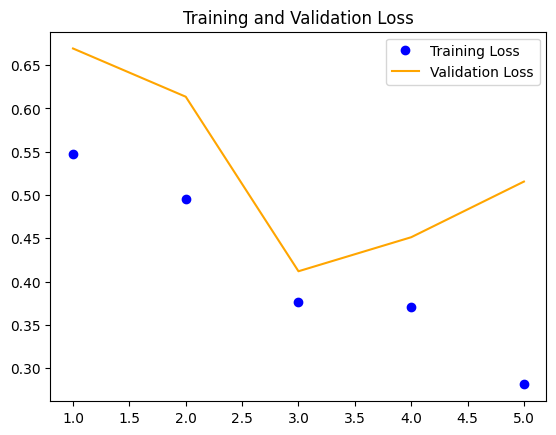

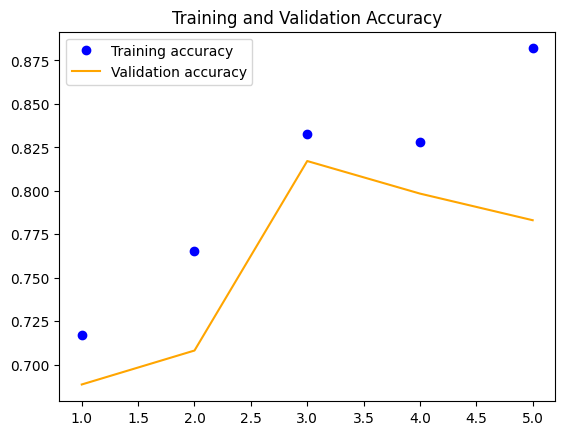

In [ ]:
plot_loss(range(1, len(loss) + 1), loss, val_loss)
plot_accuracy(range(1, len(loss) + 1), acc, val_acc)

In [ ]:

test_flow = image_gen1.flow_from_directory(
    base_path + 'test/',
    target_size=(224, 224),
    batch_size=1,
    shuffle = False,
    class_mode='binary'
)
y_pred=model.predict(test_flow)
y_test = test_flow.classes

Found 20000 images belonging to 2 classes.
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 268s 13ms/step


In [ ]:
print("ROC AUC Score:", metrics.roc_auc_score(y_test, y_pred))
print("AP Score:", metrics.average_precision_score(y_test, y_pred))
print()
print(metrics.classification_report(y_test, y_pred > 0.5))

ROC AUC Score: 0.90623846
AP Score: 0.8987239603402429

              precision    recall  f1-score   support

           0       0.93      0.60      0.73     10000
           1       0.71      0.96      0.81     10000

    accuracy                           0.78     20000
   macro avg       0.82      0.78      0.77     20000
weighted avg       0.82      0.78      0.77     20000

